In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()

In [6]:
dataset=pd.read_csv("50_Startups.csv")

In [7]:
dataset

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [8]:
dataset=pd.get_dummies(dataset, drop_first=True)

In [9]:
dataset

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,0,1
1,162597.70,151377.59,443898.53,191792.06,0,0
2,153441.51,101145.55,407934.54,191050.39,1,0
3,144372.41,118671.85,383199.62,182901.99,0,1
4,142107.34,91391.77,366168.42,166187.94,1,0
5,131876.90,99814.71,362861.36,156991.12,0,1
6,134615.46,147198.87,127716.82,156122.51,0,0
7,130298.13,145530.06,323876.68,155752.60,1,0
8,120542.52,148718.95,311613.29,152211.77,0,1
9,123334.88,108679.17,304981.62,149759.96,0,0


In [10]:
dataset.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'Profit',
       'State_Florida', 'State_New York'],
      dtype='object')

In [11]:
independent=dataset[['R&D Spend', 'Administration', 'Marketing Spend','State_Florida', 'State_New York']]

In [12]:
independent

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,0,1
1,162597.70,151377.59,443898.53,0,0
2,153441.51,101145.55,407934.54,1,0
3,144372.41,118671.85,383199.62,0,1
4,142107.34,91391.77,366168.42,1,0
5,131876.90,99814.71,362861.36,0,1
6,134615.46,147198.87,127716.82,0,0
7,130298.13,145530.06,323876.68,1,0
8,120542.52,148718.95,311613.29,0,1
9,123334.88,108679.17,304981.62,0,0


In [13]:
dependent=dataset[['Profit']]

In [14]:
dependent

,Profit
0,192261.83
1,191792.06
2,191050.39
3,182901.99
4,166187.94
5,156991.12
6,156122.51
7,155752.60
8,152211.77
9,149759.96


In [15]:
# KFold produce r2 result for each fold only which can be visualised
# Now compre r2=0.9358680970046241 from regressor.fit(X_train,y_train) after train_test_split method againt
# 10 fold of KFold.
#-----------K-Fold--------------#
kfold = KFold(
    n_splits=10,
    shuffle=True,
    random_state=0
)

scores = cross_val_score(
    estimator=regressor, #!! Regressor assigned
    X=independent,       #!! Data X and Y assigned
    y=dependent,
    cv=kfold,            #!! 
    scoring="r2"
)
#-----------K-Fold--------------#
print("="*60)
print("R2 Score for each fold:", scores)
print("Mean R2:", scores.mean())
print("Standard Deviation:", scores.std())
print("="*60)

R2 Score for each fold: [0.93480944 0.91883388 0.65415821 0.90207233 0.81189889 0.94101052
 0.92542466 0.93000386 0.84931553 0.98762829]
Mean R2: 0.8855155602591361
Standard Deviation: 0.09008265698584421


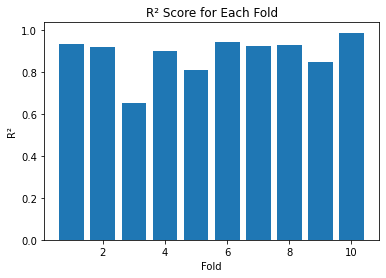

In [16]:
import matplotlib.pyplot as plt
plt.bar(range(1, 11), scores)
plt.xlabel("Fold")
plt.ylabel("R²")
plt.title("R² Score for Each Fold")
plt.show()

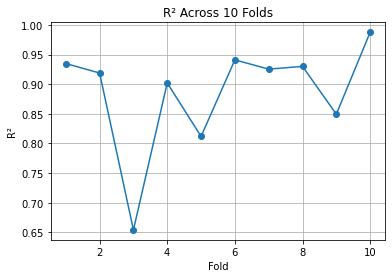

In [17]:
plt.plot(range(1,11), scores, marker='o')
plt.xlabel("Fold")
plt.ylabel("R²")
plt.title("R² Across 10 Folds")
plt.grid(True)
plt.show()

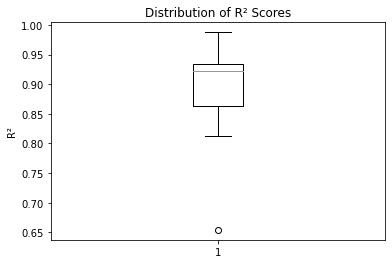

In [18]:
plt.boxplot(scores)
plt.ylabel("R²")
plt.title("Distribution of R² Scores")
plt.show()